### **Conclusions**
---
Titanic Data set contain 851 rows and 15 columns

There are 111 duplicates rows in the data set which removed

Age and Embarked columns has missing values

Dropped alive and embark_town columns  because they have same values with survival and embarked columns

Drop Deck column because it has 688 missing values

After dropping these columns we have 891 rows and 12 columns

In sex columns there are 577 males and 314 females

There  two missing values in the embarked column which imputed by sklearn 




### Importing labraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.impute import SimpleImputer

### Loading data set

In [2]:
df=sns.load_dataset('titanic')

### Have a look on five random rows of the data

In [3]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
842,1,1,female,30.0,0,0,31.0,C,First,woman,False,NaN,Cherbourg,yes,True
538,0,3,male,NaN,0,0,14.5,S,Third,man,True,NaN,Southampton,no,True
331,0,1,male,45.5,0,0,28.5,S,First,man,True,C,Southampton,no,True
480,0,3,male,9.0,5,2,46.9,S,Third,child,False,NaN,Southampton,no,False
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True


### Shape of the data

In [4]:
df.shape

(891, 15)

### Applying statics functions

In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### Columns of the data

In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

### Missing values

In [8]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Droping deck column because it has many missing values

In [9]:
df.drop('deck',axis=1,inplace=True)

In [10]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


### Droping alive column because it is similar with the the survived column

In [11]:
df.drop('alive',axis=1,inplace=True)

### Droping Embarked_town column because embarked and embarked_town has some values

In [12]:
df.drop('embark_town',axis=1,inplace=True)

In [13]:
df.shape

(891, 12)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    891 non-null    int64   
 1   pclass      891 non-null    int64   
 2   sex         891 non-null    str     
 3   age         714 non-null    float64 
 4   sibsp       891 non-null    int64   
 5   parch       891 non-null    int64   
 6   fare        891 non-null    float64 
 7   embarked    889 non-null    str     
 8   class       891 non-null    category
 9   who         891 non-null    str     
 10  adult_male  891 non-null    bool    
 11  alone       891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(3)
memory usage: 65.5 KB


 ---
Now we have 12 columns after removing three columns

---

### **Sex column**

In [15]:
df['sex']

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: sex, Length: 891, dtype: str

In [16]:
df['sex'].isnull().sum()

0

In [17]:
df['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

### **Graphical Represention**

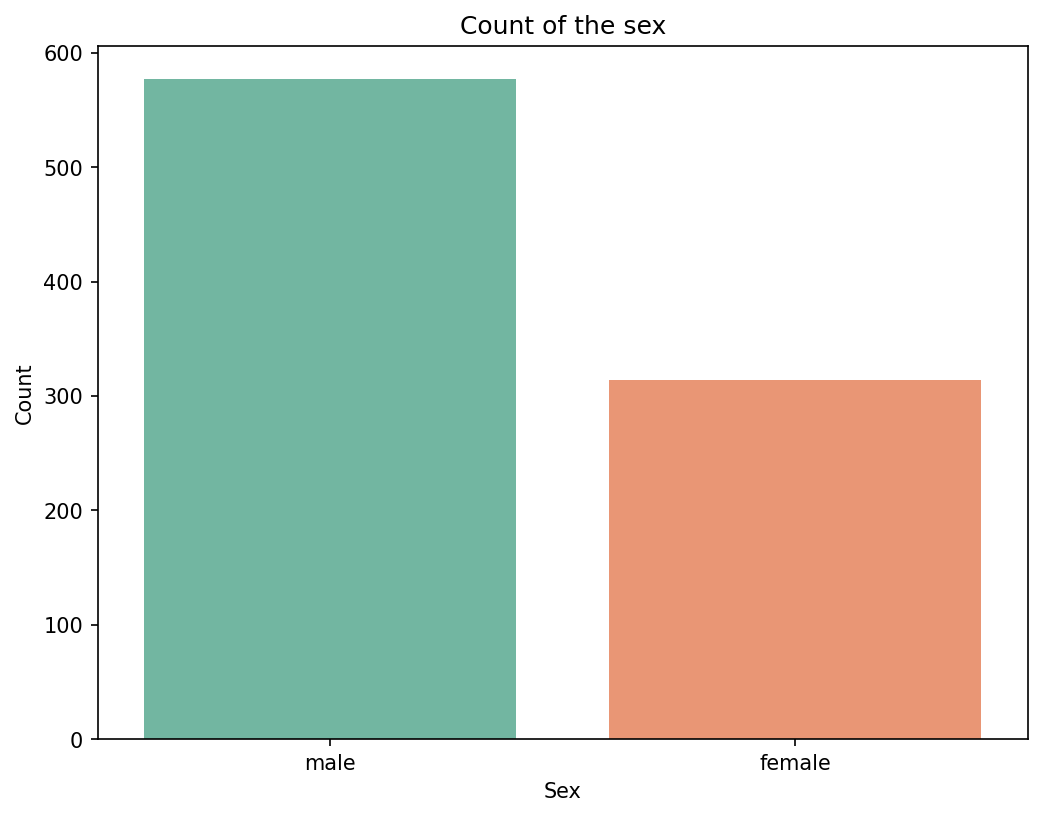

In [18]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(data=df,x='sex',palette='Set2')
plt.title('Count of the sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()


### **Embarked Column**

In [19]:
df['embarked'].head()

0    S
1    C
2    S
3    S
4    S
Name: embarked, dtype: str

In [23]:
df['embarked'].isnull().sum()

2

### Filling missing values with sklearn

In [28]:
imputer=SimpleImputer(strategy='most_frequent')
df['embarked']=imputer.fit_transform(df[['embarked']]).ravel()

In [29]:
df['embarked'].isnull().sum()

0

In [20]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

### **Graphical Represention**

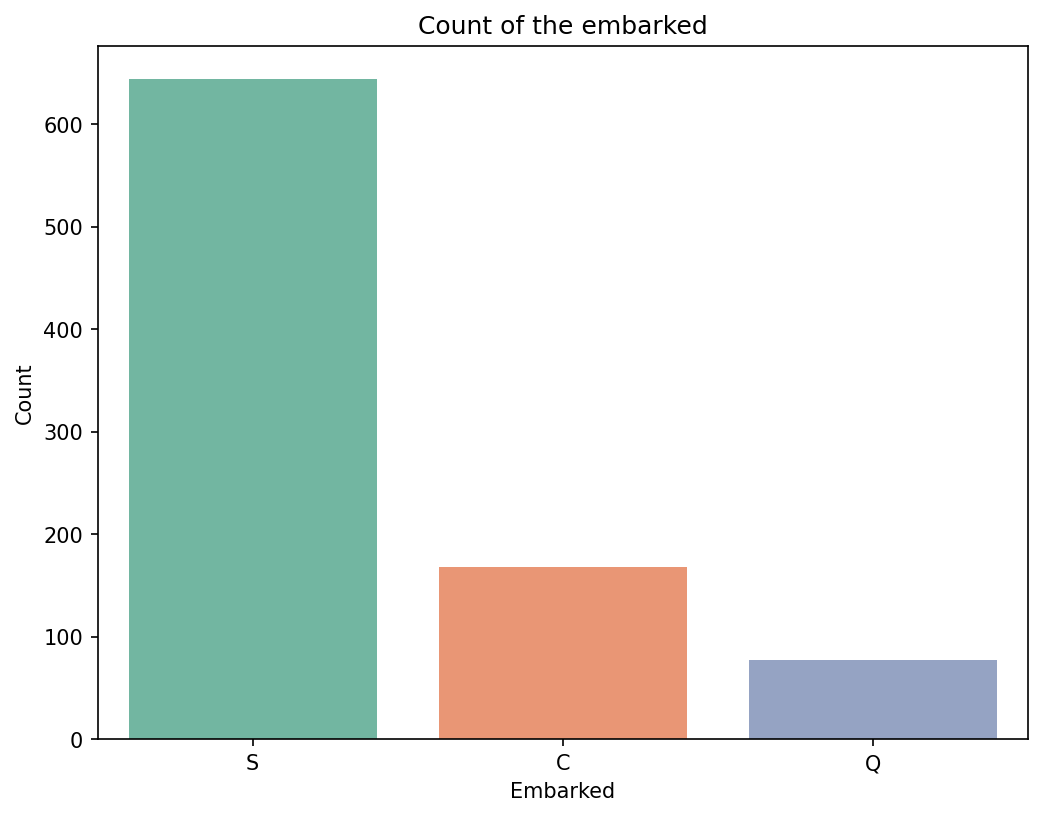

In [21]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(data=df,x='embarked',palette='Set2')
plt.title('Count of the embarked')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()

### **Survival Column**

In [22]:
df['survived'].head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

In [30]:
df['survived'].isnull().sum()

0

In [31]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

### **Graphical Represention**


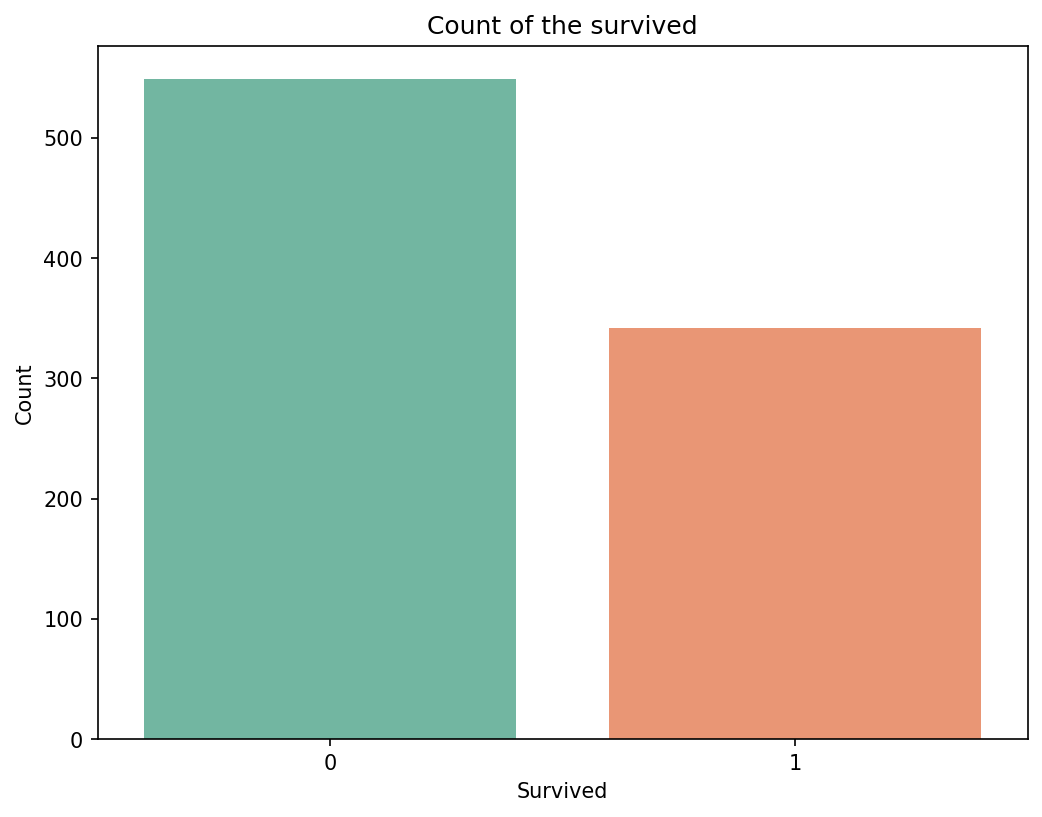

In [32]:
plt.figure(figsize=(8,6),dpi=150)
sns.countplot(data=df,x='survived',palette='Set2')
plt.title('Count of the survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()